ICI, simulateur de propagation d'épidémies

Zombie Publication.pdf 

Physics students explore feasibility of surviving zombie viral infection


## 1. The Walking Dead (Le Virus "Wildfire")
Dans l'univers de TWD, le virus est déjà présent chez tout le monde (infection latente). Le passage à l'état de zombie se fait soit par la mort naturelle, soit par une morsure qui provoque une infection bactérienne mortelle.
### Le Modèle SIR
Le modèle classique SIR (Sains, Infectés, Retirés) ne s'applique pas parfaitement ici car tout le monde est déjà "Infecté" de manière dormante. On utilise plutôt un modèle de type SDE (Sains, "Dead" ou Zombies, Éliminés).
* S (Susceptibles) : Les survivants humains.
* Z (Zombies) : Les morts-vivants qui transmettent la "mort" par morsure.
* R (Retirés) : Les zombies détruits (cerveau détruit) ou les humains dont le corps est totalement consommé.
### Le R0 estimé
Le R0 représente le nombre moyen de personnes qu'un individu infecté contamine. Pour un zombie de TWD :
* En ville (début d'épidémie) : Le R0 est potentiellement très élevé (entre 3 et 5), car la panique et la densité urbaine facilitent les morsures.
* À long terme : Le R0 chute drastiquement en dessous de 1. Les zombies sont lents, prévisibles, et les survivants deviennent des experts pour les éliminer.


## 2. The Last of Us (Le Cordyceps)
Ici, on ne parle pas d'un virus mais d'un champignon. La transmission se fait par morsure ou (dans les jeux/BD) par inhalation de spores.
### Le Modèle SIR
Le modèle est plus proche du standard car on peut être "Sain" sans porter le champignon.
* S (Sains) : Humains non infectés.
* I (Infectés) : Coureurs, Rôdeurs, Claqueurs, Colosses.
* R (Retirés) : Humains immunisés (Ellie) ou infectés morts/fixés au mur pour libérer des spores.
### Le R0 estimé
Le R0 de The Last of Us est bien plus terrifiant que celui de TWD :
* Estimation : On pourrait l'estimer entre 5 et 10 lors de l'éclatement (Outbreak Day).
* Pourquoi ? Contrairement aux zombies de TWD, les infectés de TLOU sont rapides ("Runners") et le milieu environnemental (les spores) peut infecter plusieurs personnes simultanément sans contact direct.


# Implémentation

$$\frac{dS}{dt} = - \mu S Z - \beta S Z$$
$$\frac{dZ}{dt} = \gamma R - \alpha S Z$$
$$\frac{dR}{dt} = - \gamma R + \beta S Z$$
$$\frac{dD}{dt} = \alpha S Z + \mu S Z$$

$\alpha$ : Zombie a qui ont a coupé la tête

$\gamma$ : Délai d'attente avant d'être un zombie (temps d'incubation)

$\mu$ : Humains entièrement consommé par un zombie

$\beta$ : Humains contaminés par un zombie (morsure)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import nosPackages.mathUtils as mathUtils

# population initial
S_init=0.999 # personnes suscétibles (départ) en fraction -> 1=100%
Z_init=0.001 # personnes zombies
R_init=0 # personnes en statut quo, elles sont infectés mais ne sont pas encore zombie (ne peuvent pas infecter)
D_init=0 # personnes qui meurent

# paramètre de contagion
beta=5 # Contaminé par un zombie
gamma=0.2 # Délai d'attente avant de devenir zombie
mu= 2 # Humain consommé par le zombie
alpha= 0.0001 # Zombie qui est mort
R0=beta/gamma*S_init # nombre de personnes contaminés par un malade = 3 pour le covid

In [4]:
dt = 0.1
tmax = 100.0
temps = np.arange(0, tmax + dt, dt)
n = temps.size

S = np.empty(n)
Z = np.empty(n)
R = np.empty(n)
D = np.empty(n)
Rt = np.empty(n)

y = np.empty(4)
y[0] = S_init
y[1] = Z_init
y[2] = Z_init
y[3] = D_init

params={"beta":beta,"gamma":gamma, "mu":mu, "alpha":alpha}
model=mathUtils.ZOMBIE(params)
deriv=model.deriv_ZOMBIE
euler=model.euler

for i in range(n):
    S[i] = y[0]
    Z[i] = y[1]
    R[i] = y[2]
    D[i] = y[3]
    t = temps[i]
    y = euler(t, dt, y, deriv)
Rt = R0*S # evolution du R0 (contagion pour une personne)

In [5]:
"""plt.figure()
plt.title("Evolution de S(t)")
plt.plot(temps, S)
plt.xlabel("temps")
plt.ylabel("S(t)")
plt.savefig("sird_S.pdf", bbox_inches='tight')
plt.show()

plt.figure()
plt.title("Evolution de I(t)")
plt.plot(temps, I)
plt.xlabel("temps")
plt.ylabel("I(t)")
plt.savefig("sird_I.pdf", bbox_inches='tight')
plt.show()

plt.figure()
plt.title("Evolution de R(t)")
plt.plot(temps, R)
plt.xlabel("temps")
plt.ylabel("R(t)")
plt.savefig("sird_R.pdf", bbox_inches='tight')
plt.show()

plt.figure()
plt.title("Evolution de D(t)")
plt.plot(temps, D)
plt.xlabel("temps")
plt.ylabel("D(t)")
plt.savefig("sird_R.pdf", bbox_inches='tight')
plt.show()

plt.figure()
plt.title("Evolution de Rt")
plt.plot(temps, Rt)
plt.xlabel("temps")
plt.ylabel("Rt")
plt.savefig("sird_Rt.pdf", bbox_inches='tight')
plt.show()
"""

'plt.figure()\nplt.title("Evolution de S(t)")\nplt.plot(temps, S)\nplt.xlabel("temps")\nplt.ylabel("S(t)")\nplt.savefig("sird_S.pdf", bbox_inches=\'tight\')\nplt.show()\n\nplt.figure()\nplt.title("Evolution de I(t)")\nplt.plot(temps, I)\nplt.xlabel("temps")\nplt.ylabel("I(t)")\nplt.savefig("sird_I.pdf", bbox_inches=\'tight\')\nplt.show()\n\nplt.figure()\nplt.title("Evolution de R(t)")\nplt.plot(temps, R)\nplt.xlabel("temps")\nplt.ylabel("R(t)")\nplt.savefig("sird_R.pdf", bbox_inches=\'tight\')\nplt.show()\n\nplt.figure()\nplt.title("Evolution de D(t)")\nplt.plot(temps, D)\nplt.xlabel("temps")\nplt.ylabel("D(t)")\nplt.savefig("sird_R.pdf", bbox_inches=\'tight\')\nplt.show()\n\nplt.figure()\nplt.title("Evolution de Rt")\nplt.plot(temps, Rt)\nplt.xlabel("temps")\nplt.ylabel("Rt")\nplt.savefig("sird_Rt.pdf", bbox_inches=\'tight\')\nplt.show()\n'

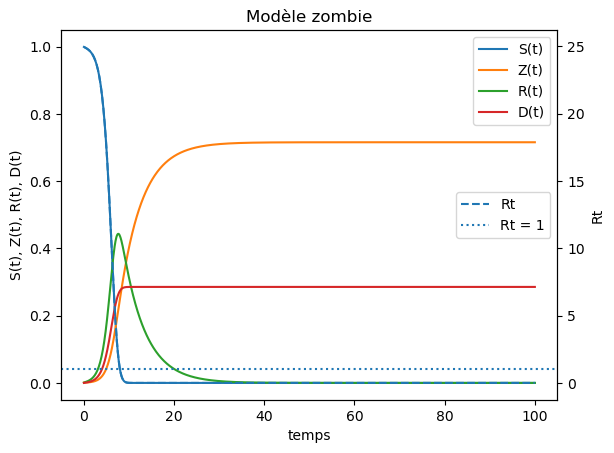

In [7]:
plt.figure()
plt.title("Modèle zombie")

ax1 = plt.gca()
ax1.plot(temps, S, label="S(t)")
ax1.plot(temps, Z, label="Z(t)")
ax1.plot(temps, R, label="R(t)")
ax1.plot(temps, D, label="D(t)")
ax1.set_xlabel("temps")
ax1.set_ylabel("S(t), Z(t), R(t), D(t)")
ax1.legend(loc="upper right")

ax2 = ax1.twinx()
ax2.plot(temps, Rt, "--", label="Rt")
ax2.axhline(1, linestyle=":", label="Rt = 1")
ax2.set_ylabel("Rt")
ax2.legend(loc="center right")

plt.savefig("sir_zombie.pdf", bbox_inches='tight')
plt.show()